# AI 기반 소상공인 조기경보(Early Warning) 시스템
## 서울시 상권 데이터를 활용한 폐업위험 예측 및 Explainable AI 기반 의사결정 지원


1. 서울시 상권 데이터를 활용해 상권별 폐업위험을 예측하고
2. Explainable AI 기법을 통해 어떤 요인이 폐업위험에 영향을 미쳤는지 해석하여 
3. 소상공인·정책기관의 의사결정을 지원하는 조기경보 시스템을 구축했다.


[문제 정의]

기존 소상공인 지원은 폐업 이후 지원이나 단순 현황 분석에 그치는 경우가 많다.
따라서 상권별 매출, 점포 수, 유동인구, 생활인구, 임대료, 업종 특성 등을 활용해 폐업위험을 사전에 예측하는 모델을 만들고자 했다.

[분석 목표]

- 서울시 상권별 폐업률 산출
- 폐업위험에 영향을 주는 주요 요인 탐색
- 머신러닝 기반 폐업위험 예측 모델 구축
- Feature Importance / Permutation Importance 기반 해석
- 위험 상권을 조기에 탐지하는 의사결정 지원 구조 제안

## 0. 데이터 불러오기

In [1]:
# 필요 라이브러리 불러오기
import os
import re
import glob
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import sys
!{sys.executable} -m pip install xgboost lightgbm

# 데이터 형식 보기 쉽게
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# 한글 폰트 설정: Mac/Windows/Linux 대응
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print('환경 준비 완료')

환경 준비 완료


## 1. 사용 데이터와 활용 이유

| 데이터 | 기준 단위 | 활용 이유 |
|---|---|---|
| 점포 데이터 | 행정동 + 업종 + 분기 | 점포 수, 개업률, 폐업률, 프랜차이즈 수 파악 |
| 추정매출 | 행정동 + 업종 + 분기 | 수익성 및 현금창출력의 선행지표 |
| 직장인구 | 행정동 + 분기 | 오피스 상권, 점심 수요 설명 |
| 상주인구 | 행정동 + 분기 | 배후 주거수요 설명 |
| 길단위인구 | 행정동 + 분기 | 유동수요 설명 |
| 상권변화지표 | 행정동 + 분기 | 상권의 성장/정체/쇠퇴 흐름 설명 |
| 아파트 데이터 | 상권 기준 | 공간 단위가 달라 이번 Part 1 모델링 데이터에서는 제외 |

중요한 원칙은 **공간 단위를 행정동 기준으로 통일**하는 것입니다. 점포 데이터가 행정동 기준이므로 다른 데이터도 행정동 기준으로 병합합니다.

In [2]:
# - 파일명 유니코드 정규화
# - 파일 분류 결과를 표로 출력
# - 데이터가 하나도 잡히지 않으면 즉시 에러 발생
# - 중복 파일이 있어도 키 기준으로 중복 제거

# 데이터 경로 설정
candidate_dirs = [Path.cwd() / 'data']
all_files = []
for d in candidate_dirs:
    if d.exists():
        all_files.extend(list(d.glob('*.csv')))

def norm_name(path):
    # Mac 한글 파일명 문제를 줄이기 위해 NFC 정규화
    return unicodedata.normalize('NFC', Path(path).name)

file_groups = {
    'store': [],
    'sales': [],
    'worker': [],
    'resident': [],
    'floating': [],
    'change': [],
    'apartment': [],
    'unknown': []
}

for p in all_files:
    name = norm_name(p)
    if '점포-행정동' in name:
        file_groups['store'].append(p)
    elif '추정매출-행정동' in name:
        file_groups['sales'].append(p)
    elif '직장인구-행정동' in name:
        file_groups['worker'].append(p)
    elif '상주인구-행정동' in name:
        file_groups['resident'].append(p)
    elif '길단위인구-행정동' in name:
        file_groups['floating'].append(p)
    elif '상권변화지표-행정동' in name:
        file_groups['change'].append(p)
    elif '아파트-상권' in name:
        file_groups['apartment'].append(p)
    else:
        file_groups['unknown'].append(p)

summary = pd.DataFrame({
    'data_type': list(file_groups.keys()),
    'file_count': [len(v) for v in file_groups.values()],
    'example_file': [v[0].name if len(v)>0 else '' for v in file_groups.values()]
})
display(summary)

if len(file_groups['store']) == 0:
    raise FileNotFoundError('점포-행정동 파일을 찾지 못했습니다. 파일명에 "점포-행정동"이 포함되어 있는지 확인하세요.')

,data_type,file_count,example_file
0,store,5,서울시 상권분석서비스(점포-행정동)_20...
1,sales,5,서울시_상권분석서비스(추정매출-행정도...
2,worker,1,서울시 상권분석서비스(직장인구-행정동).csv
3,resident,1,서울시 상권분석서비스(상주인구-행정동).csv
4,floating,1,서울시 상권분석서비스(길단위인구-행정동).csv
5,change,1,서울시 상권분석서비스(상권변화지표-행정동).csv
6,apartment,1,서울시 상권분석서비스(아파트-상권).csv
7,unknown,0,


In [3]:
def read_csv_safely(path):
    # 여러 인코딩을 시도하여 CSV를 안전하게 읽는다.
    encodings = ['cp949', 'utf-8-sig', 'utf-8']
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def load_many(paths, name='data'):
    # 여러 CSV를 읽고 합친다.
    frames = []
    for p in paths:
        df_tmp = read_csv_safely(p)
        df_tmp['source_file'] = Path(p).name
        frames.append(df_tmp)
        print(f'읽기 완료: {name:10s} | {Path(p).name} | {df_tmp.shape}')
    if len(frames) == 0:
        print(f'{name}: 읽을 파일이 없습니다.')
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    print(f'{name} 전체 크기: {out.shape}')
    return out

## 2. 원본 데이터 불러오기

In [4]:
# 컬럼명 바꾸지 않고 원본 크기 확인 -> 이후 병합과정에서 행이 비정상적으로 늘거나 줄어드는거 검증하기 위함

store_raw = load_many(file_groups['store'], 'store')
sales_raw = load_many(file_groups['sales'], 'sales')
worker_raw = load_many(file_groups['worker'], 'worker')
resident_raw = load_many(file_groups['resident'], 'resident')
floating_raw = load_many(file_groups['floating'], 'floating')
change_raw = load_many(file_groups['change'], 'change')
apartment_raw = load_many(file_groups['apartment'], 'apartment')

# print('\n원본 데이터 크기 요약')
raw_shapes = pd.DataFrame({
    'dataset': ['store','sales','worker','resident','floating','change','apartment'],
    'rows': [len(store_raw), len(sales_raw), len(worker_raw), len(resident_raw), len(floating_raw), len(change_raw), len(apartment_raw)],
    'cols': [store_raw.shape[1], sales_raw.shape[1], worker_raw.shape[1], resident_raw.shape[1], floating_raw.shape[1], change_raw.shape[1], apartment_raw.shape[1]]
})
display(raw_shapes)

읽기 완료: store      | 서울시 상권분석서비스(점포-행정동)_2023년.csv | (141235, 13)
읽기 완료: store      | 서울시_상권분석서비스(점포-행정동)_2021년.csv | (140395, 13)
읽기 완료: store      | 서울시 상권분석서비스(점포-행정동)_2025년.csv | (141218, 13)
읽기 완료: store      | 서울시_상권분석서비스(점포-행정동)_2022년.csv | (140621, 13)
읽기 완료: store      | 서울시 상권분석서비스(점포-행정동)_2024년.csv | (141001, 13)
store 전체 크기: (704470, 13)
읽기 완료: sales      | 서울시_상권분석서비스(추정매출-행정동)_2021년.csv | (70071, 54)
읽기 완료: sales      | 서울시 상권분석서비스(추정매출-행정동)_2024년.csv | (67900, 54)
읽기 완료: sales      | 서울시_상권분석서비스(추정매출-행정동)_2023년.csv | (68643, 54)
읽기 완료: sales      | 서울시 상권분석서비스(추정매출-행정동)_2025년.csv | (67113, 54)
읽기 완료: sales      | 서울시_상권분석서비스(추정매출-행정동)_2022년.csv | (69440, 54)
sales 전체 크기: (343167, 54)
읽기 완료: worker     

,dataset,rows,cols
0,store,704470,13
1,sales,343167,54
2,worker,8694,25
3,resident,8925,28
4,floating,8925,26
5,change,8925,10
6,apartment,30790,21


In [5]:
store_raw['폐업_률'].describe()
[c for c in store_raw.columns if '점포' in c]

['점포_수', '유사_업종_점포_수', '개업_점포_수', '폐업_점포_수', '프랜차이즈_점포_수']

In [6]:
store_raw[store_raw['폐업_률'] == 400][
    ['점포_수', '폐업_점포_수', '폐업_률']
].head(20)

,점포_수,폐업_점포_수,폐업_률
562030,1,4,400


In [7]:
(
    store_raw['폐업_점포_수'] /
    store_raw['점포_수'] * 100
).head()

0   4.0541
1   0.0000
2   0.0000
3   4.1667
4   0.0000
dtype: float64

In [8]:
store_raw['폐업_률'].head()

0    4
1    0
2    0
3    4
4    0
Name: 폐업_률, dtype: int64

In [9]:
# 현재 운영 + 폐업 = 해당 분기 동안 존재했던 점포 수로 가정 => 폐업률 변수 수정(기존과)
store_raw['폐업_률'] = (
    store_raw['폐업_점포_수'] /
    (store_raw['점포_수'] + store_raw['폐업_점포_수'])
) * 100

In [10]:
store_raw['폐업_률'].head()

0   3.8961
1   0.0000
2   0.0000
3   4.0000
4   0.0000
Name: 폐업_률, dtype: float64

## 3. 컬럼 표준화

- 영어 컬럼명이 코딩에서 더 안정적
- 핵심 컬럼만 선택 + 분석에 필요한 이름으로 바꿈

[중요한 병합 키]

- 점포 + 매출: `quarter + dong_code + service_code`
- 점포 + 인구/상권변화: `quarter + dong_code`

In [11]:
def to_str_code(s):
    return s.astype(str).str.strip()  # 데이터를 문자열(String) 형태로 변환하고, 앞뒤 공백을 제거하는 함수

def basic_quarter_cols(df):
    df['quarter'] = pd.to_numeric(df['quarter'], errors='coerce').astype('Int64')
    df['year'] = (df['quarter'] // 10).astype('Int64') # 년
    df['qtr'] = (df['quarter'] % 10).astype('Int64') # 분기
    return df

# 6-1. 점포 데이터
store_cols = {
    '기준_년분기_코드': 'quarter',
    '행정동_코드': 'dong_code',
    '행정동_코드_명': 'dong',
    '서비스_업종_코드': 'service_code',
    '서비스_업종_코드_명': 'service',
    '점포_수': 'store_cnt',
    '유사_업종_점포_수': 'similar_store_cnt',
    '개업_율': 'open_rate',
    '개업_점포_수': 'open_store_cnt',
    '폐업_률': 'close_rate',
    '폐업_점포_수': 'close_store_cnt',
    '프랜차이즈_점포_수': 'franchise_store_cnt'
}
store = store_raw.rename(columns=store_cols)[list(store_cols.values())].copy()
store['dong_code'] = to_str_code(store['dong_code'])
store['service_code'] = to_str_code(store['service_code'])
store = basic_quarter_cols(store)
num_cols_store = ['store_cnt','similar_store_cnt','open_rate','open_store_cnt','close_rate','close_store_cnt','franchise_store_cnt']
for c in num_cols_store:
    store[c] = pd.to_numeric(store[c], errors='coerce')
store = store.drop_duplicates(['quarter','dong_code','service_code']).reset_index(drop=True)
print('store 표준화 후:', store.shape)
display(store.head())

store 표준화 후: (704470, 14)


,quarter,dong_code,dong,service_code,service,store_cnt,similar_store_cnt,open_rate,open_store_cnt,close_rate,close_store_cnt,franchise_store_cnt,year,qtr
0,20231,11110515,청운효자동,CS100001,한식음식점,74,75,4,3,3.8961,3,1,2023,1
1,20231,11110515,청운효자동,CS100002,중식음식점,4,4,0,0,0.0000,0,0,2023,1
2,20231,11110515,청운효자동,CS100003,일식음식점,17,18,0,0,0.0000,0,1,2023,1
3,20231,11110515,청운효자동,CS100004,양식음식점,48,48,2,1,4.0000,2,0,2023,1
4,20231,11110515,청운효자동,CS100005,제과점,23,24,0,0,0.0000,0,1,2023,1


In [12]:
# 6-2. 추정매출 데이터
if not sales_raw.empty:
    sales_cols = {
        '기준_년분기_코드': 'quarter',
        '행정동_코드': 'dong_code',
        '서비스_업종_코드': 'service_code',
        '당월_매출_금액': 'sales_amt',
        '당월_매출_건수': 'sales_cnt',
        '주중_매출_금액': 'weekday_sales_amt',
        '주말_매출_금액': 'weekend_sales_amt'
    }
    sales = sales_raw.rename(columns=sales_cols)[list(sales_cols.values())].copy()
    sales['dong_code'] = to_str_code(sales['dong_code'])
    sales['service_code'] = to_str_code(sales['service_code'])
    sales = basic_quarter_cols(sales)
    for c in ['sales_amt','sales_cnt','weekday_sales_amt','weekend_sales_amt']:
        sales[c] = pd.to_numeric(sales[c], errors='coerce')
    # 혹시 중복이 있으면 합산한다.
    sales = sales.groupby(['quarter','dong_code','service_code'], as_index=False).agg({
        'sales_amt':'sum',
        'sales_cnt':'sum',
        'weekday_sales_amt':'sum',
        'weekend_sales_amt':'sum'
    })
else:
    sales = pd.DataFrame()
print('sales 표준화 후:', sales.shape)
display(sales.head())

sales 표준화 후: (343167, 7)


,quarter,dong_code,service_code,sales_amt,sales_cnt,weekday_sales_amt,weekend_sales_amt
0,20211,11110515,CS100001,2415161270,80254,1818467815,596693455
1,20211,11110515,CS100002,298701226,11244,193508111,105193115
2,20211,11110515,CS100003,171716236,9426,120592649,51123587
3,20211,11110515,CS100004,2454663973,29974,1459732990,994930983
4,20211,11110515,CS100005,407037054,35565,269696189,137340865


In [13]:
# 6-3. 행정동+분기 단위 데이터 표준화 함수

def standardize_area_quarter(df_raw, col_map, agg_map, name):
    if df_raw.empty:
        return pd.DataFrame()
    df = df_raw.rename(columns=col_map)[list(col_map.values())].copy()
    df['dong_code'] = to_str_code(df['dong_code'])
    df = basic_quarter_cols(df)
    for c in agg_map.keys():
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    group_keys = ['quarter','dong_code']
    df = df.groupby(group_keys, as_index=False).agg(agg_map)
    print(f'{name} 표준화 후:', df.shape)
    return df

worker = standardize_area_quarter(
    worker_raw,
    {'기준_년분기_코드':'quarter','행정동_코드':'dong_code','총_직장_인구_수':'worker_pop_total'},
    {'worker_pop_total':'sum'},
    'worker'
)

resident = standardize_area_quarter(
    resident_raw,
    {'기준_년분기_코드':'quarter','행정동_코드':'dong_code','총_상주인구_수':'resident_pop_total'},
    {'resident_pop_total':'sum'},
    'resident'
)

floating = standardize_area_quarter(
    floating_raw,
    {'기준_년분기_코드':'quarter','행정동_코드':'dong_code','총_유동인구_수':'floating_pop_total'},
    {'floating_pop_total':'sum'},
    'floating'
)

# 상권변화지표는 범주형+숫자형이 섞여 있음
if not change_raw.empty:
    change = change_raw.rename(columns={
        '기준_년분기_코드':'quarter',
        '행정동_코드':'dong_code',
        '상권_변화_지표':'change_indicator',
        '상권_변화_지표_명':'change_indicator_name',
        '운영_영업_개월_평균':'avg_operating_months',
        '폐업_영업_개월_평균':'avg_closed_months'
    })[['quarter','dong_code','change_indicator','change_indicator_name','avg_operating_months','avg_closed_months']].copy()
    change['dong_code'] = to_str_code(change['dong_code'])
    change = basic_quarter_cols(change)
    change['avg_operating_months'] = pd.to_numeric(change['avg_operating_months'], errors='coerce')
    change['avg_closed_months'] = pd.to_numeric(change['avg_closed_months'], errors='coerce')
    change = change.drop_duplicates(['quarter','dong_code']).reset_index(drop=True)
else:
    change = pd.DataFrame()
print('change 표준화 후:', change.shape)
display(change.head())

worker 표준화 후: (8694, 3)
resident 표준화 후: (8925, 3)
floating 표준화 후: (8925, 3)
change 표준화 후: (8925, 8)


,quarter,dong_code,change_indicator,change_indicator_name,avg_operating_months,avg_closed_months,year,qtr
0,20261,11740700,HL,상권축소,124,52,2026,1
1,20261,11740690,LH,상권확장,30,65,2026,1
2,20261,11740685,LL,다이나믹,114,48,2026,1
3,20261,11740660,HL,상권축소,118,49,2026,1
4,20261,11740650,LL,다이나믹,113,47,2026,1


## 4. 아파트 데이터 처리 방침

> 아파트 데이터는 상권 단위로 제공되어 행정동 기준 테이블과 공간 단위가 다르므로, 무리하게 병합하지 않고 이번 모델링에서는 제외하였다. 향후 상권영역 공간데이터를 활용한 QGIS 공간조인을 통해 확장할 수 있다.

## 5. 데이터 병합

이번 프로젝트에서 가장 중요한 발견 = 점포 데이터와 추정 매출 데이터의 행 수 다르다는 점

- 점포 데이터: 행정동 × 업종 × 분기 전체에 가까운 데이터
- 추정매출 데이터: 서울시가 추정매출을 제공하는 업종에 한정된 데이터

따라서 병합 후 매출 결측이 생기는 것은 병합 오류가 아니라 **데이터 제공 범위 차이**일 수 있습니다. 이를 코드로 검증합니다.

In [14]:
print('store 크기:', store.shape)
print('sales 크기:', sales.shape)

if not sales.empty:
    print('store key 중복:', store.duplicated(['quarter','dong_code','service_code']).sum())
    print('sales key 중복:', sales.duplicated(['quarter','dong_code','service_code']).sum())
    print('store key 개수:', store[['quarter','dong_code','service_code']].drop_duplicates().shape)
    print('sales key 개수:', sales[['quarter','dong_code','service_code']].drop_duplicates().shape)
    print('매출 제공 비율(키 기준):', len(sales) / len(store) * 100)

store 크기: (704470, 14)
sales 크기: (343167, 7)
store key 중복: 0
sales key 중복: 0
store key 개수: (704470, 3)
sales key 개수: (343167, 3)
매출 제공 비율(키 기준): 48.71279117634534


In [15]:
# 병합 수행
# 매출은 행정동+업종+분기 단위로 병합한다.
# 인구 및 상권변화 데이터는 행정동+분기 단위로 병합한다.

df = store.copy()

if not sales.empty:
    df = df.merge(
        sales,
        on=['quarter','dong_code','service_code'],
        how='left',
        validate='1:1'
    )

for data_name, data in [('worker', worker), ('resident', resident), ('floating', floating), ('change', change)]:
    if not data.empty:
        before = df.shape
        df = df.merge(data, on=['quarter','dong_code'], how='left', validate='m:1')
        print(f'{data_name} 병합 완료: {before} → {df.shape}')

print('최종 병합 데이터 크기:', df.shape)
display(df.head())

worker 병합 완료: (704470, 18) → (704470, 19)
resident 병합 완료: (704470, 19) → (704470, 20)
floating 병합 완료: (704470, 20) → (704470, 21)
change 병합 완료: (704470, 21) → (704470, 27)
최종 병합 데이터 크기: (704470, 27)


,quarter,dong_code,dong,service_code,service,store_cnt,similar_store_cnt,open_rate,open_store_cnt,close_rate,close_store_cnt,franchise_store_cnt,year_x,qtr_x,sales_amt,sales_cnt,weekday_sales_amt,weekend_sales_amt,worker_pop_total,resident_pop_total,floating_pop_total,change_indicator,change_indicator_name,avg_operating_months,avg_closed_months,year_y,qtr_y
0,20231,11110515,청운효자동,CS100001,한식음식점,74,75,4,3,3.8961,3,1,2023,1,"3,251,331,172.0000","99,863.0000","2,353,732,919.0000","897,598,253.0000","6,746.0000",13009,3555653,LH,상권확장,91,53,2023,1
1,20231,11110515,청운효자동,CS100002,중식음식점,4,4,0,0,0.0000,0,0,2023,1,"296,642,191.0000","8,631.0000","191,061,126.0000","105,581,065.0000","6,746.0000",13009,3555653,LH,상권확장,91,53,2023,1
2,20231,11110515,청운효자동,CS100003,일식음식점,17,18,0,0,0.0000,0,1,2023,1,"347,904,187.0000","14,534.0000","259,612,600.0000","88,291,587.0000","6,746.0000",13009,3555653,LH,상권확장,91,53,2023,1
3,20231,11110515,청운효자동,CS100004,양식음식점,48,48,2,1,4.0000,2,0,2023,1,"2,473,618,713.0000","41,012.0000","1,526,246,790.0000","947,371,923.0000","6,746.0000",13009,3555653,LH,상권확장,91,53,2023,1
4,20231,11110515,청운효자동,CS100005,제과점,23,24,0,0,0.0000,0,1,2023,1,"377,988,895.0000","31,952.0000","245,689,985.0000","132,298,910.0000","6,746.0000",13009,3555653,LH,상권확장,91,53,2023,1


In [16]:
df['close_rate'].describe()

count   701,555.0000
mean          2.6535
std           8.4236
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max         100.0000
Name: close_rate, dtype: float64

## 6. 결측치 분석

결측치는 단순히 채우면 안 됩니다. 특히 매출 데이터의 결측은 다음 두 경우를 구분해야 합니다.

1. 실제 매출이 0인 경우
2. 서울시에서 해당 업종의 추정매출을 제공하지 않는 경우

현재 데이터에서는 추정매출 데이터의 행 수 자체가 점포 데이터보다 적기 때문에, 매출 결측은 상당 부분 **데이터 제공 범위 차이**로 해석하는 것이 타당합니다.

In [17]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_rate_pct': df.isnull().mean() * 100
}).sort_values('missing_rate_pct', ascending=False)

missing_nonzero = missing[missing['missing_count'] > 0]
display(missing_nonzero)

,missing_count,missing_rate_pct
sales_amt,361303,51.2872
weekend_sales_amt,361303,51.2872
weekday_sales_amt,361303,51.2872
sales_cnt,361303,51.2872
worker_pop_total,14083,1.9991
close_rate,2915,0.4138


### 6-1. 매출 결측의 원인 확인

- 특정 서비스업종에 결측이 몰려있다면, 해당 업종의 매출 데이터가 제공되지 않는 구조적 결측일 수 있음

In [18]:
if 'sales_amt' in df.columns:
    print('전체 행 수:', len(df))
    print('매출 결측 행 수:', df['sales_amt'].isnull().sum())
    print('매출 결측률(%):', df['sales_amt'].isnull().mean() * 100)
    display(df[df['sales_amt'].isnull()]['service'].value_counts().head(50).to_frame('missing_sales_count'))

전체 행 수: 704470
매출 결측 행 수: 361303
매출 결측률(%): 51.28720882365466


,missing_sales_count
service,
사진관,8460
건축물청소,8424
독서실,8152
여행사,7978
통번역서비스,7902
부동산중개업,7899
자동차부품,7635
동물병원,7139
재생용품 판매점,7081


## 7. 결측치 처리

분석 목적에 따라 두 개의 데이터셋을 분리합니다.

### 1. 전체 상권 분석용 데이터 `df_all`
- 전체 업종을 포함합니다.
- 폐업률 분포, 업종별 폐업률, 지역별 폐업률 등 EDA에 사용합니다.

### 2. 매출 기반 모델링 데이터 `df_sales_model`
- 추정매출이 존재하는 업종만 사용합니다.
- 매출 결측을 0이나 평균으로 대체하지 않습니다.
- 이유: 매출 데이터가 없는 업종에 임의의 매출 값을 넣으면 수익성 변수가 왜곡됩니다.

직장인구 등 결측률이 낮은 변수는 중앙값으로 대체합니다. 단, 모델링 단계에서는 가능하면 Pipeline 내부의 `SimpleImputer`를 사용해 데이터 누수를 방지합니다.

In [19]:
df_all = df.copy()

# 매출 기반 분석/모델링 데이터
required_sales_cols = ['sales_amt','sales_cnt','weekday_sales_amt','weekend_sales_amt']
existing_sales_cols = [c for c in required_sales_cols if c in df.columns]

df_sales_model = df.dropna(subset=existing_sales_cols).copy()

print('전체 데이터:', df_all.shape)
print('매출 기반 데이터:', df_sales_model.shape)
print('매출 기반 데이터 비율(%):', len(df_sales_model) / len(df_all) * 100)

# 결측률이 낮은 인구 변수는 EDA 편의를 위해 중앙값 대체 버전도 준비
low_missing_numeric = ['worker_pop_total','resident_pop_total','floating_pop_total']
for c in low_missing_numeric:
    if c in df_sales_model.columns:
        df_sales_model[c] = df_sales_model[c].fillna(df_sales_model[c].median())

# 상권변화지표 범주형 결측 처리
for c in ['change_indicator','change_indicator_name']:
    if c in df_sales_model.columns:
        df_sales_model[c] = df_sales_model[c].fillna('Unknown')

print('df_sales_model 결측 상위')
display(df_sales_model.isnull().mean().mul(100).sort_values(ascending=False).head(20).to_frame('missing_rate_pct'))

전체 데이터: (704470, 27)
매출 기반 데이터: (343167, 27)
매출 기반 데이터 비율(%): 48.71279117634534
df_sales_model 결측 상위


,missing_rate_pct
close_rate,0.1760
quarter,0.0000
sales_amt,0.0000
year_y,0.0000
avg_closed_months,0.0000
avg_operating_months,0.0000
change_indicator_name,0.0000
change_indicator,0.0000
floating_pop_total,0.0000
resident_pop_total,0.0000


## 8. 폐업률 분포 확인

앞서 확인한 것처럼 `close_rate`는 0이 매우 많습니다. 이는 행정동 × 업종 × 분기 단위에서 해당 분기에 폐업이 발생하지 않은 경우가 많기 때문입니다.

따라서 전체 데이터를 바로 A/B/C/D 등급으로 균등 분할하는 `qcut`은 적절하지 않을 수 있습니다. 25%, 50%, 75% 분위수가 모두 0이면 등급 기준을 만들 수 없기 때문입니다.

,close_rate
count,"701,555.0000"
mean,2.6535
std,8.4236
min,0.0000
25%,0.0000
50%,0.0000
75%,0.0000
max,100.0000


폐업률이 0인 비율: 76.27%
close_rate 99% 분위수: 37.5


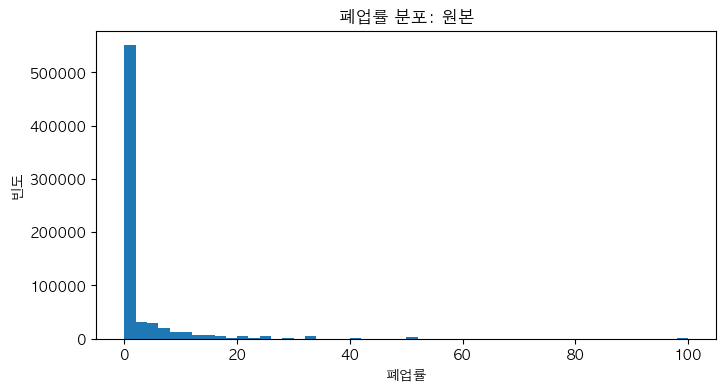

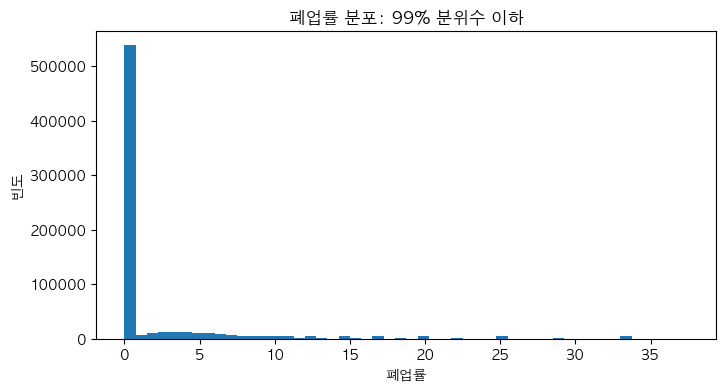

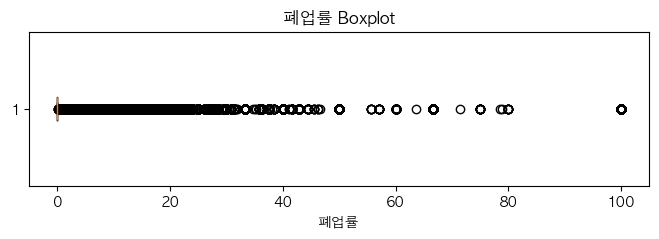

In [20]:
display(df_all['close_rate'].describe().to_frame())
zero_rate = (df_all['close_rate'] == 0).mean() * 100
print(f'폐업률이 0인 비율: {zero_rate:.2f}%')

# 이상치가 커서 원본 히스토그램과 99% 분위수 이하 히스토그램을 함께 본다.
q99 = df_all['close_rate'].quantile(0.99)
print('close_rate 99% 분위수:', q99)

plt.figure(figsize=(8,4))
plt.hist(df_all['close_rate'].dropna(), bins=50)
plt.title('폐업률 분포: 원본')
plt.xlabel('폐업률')
plt.ylabel('빈도')
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df_all.loc[df_all['close_rate'] <= q99, 'close_rate'].dropna(), bins=50)
plt.title('폐업률 분포: 99% 분위수 이하')
plt.xlabel('폐업률')
plt.ylabel('빈도')
plt.show()

plt.figure(figsize=(8,2))
plt.boxplot(df_all['close_rate'].dropna(), vert=False)
plt.title('폐업률 Boxplot')
plt.xlabel('폐업률')
plt.show()

## 8-1. 위험등급 설정 방식

이 데이터는 폐업률 0이 많으므로 전체 데이터에 `qcut`을 적용하면 실패하거나 의미 없는 구간이 생깁니다.

따라서 EDA에서는 다음처럼 정의합니다.

- **저위험 상권:** 현재 분기 폐업률이 0인 행정동-업종
- **고위험 상권:** 폐업이 발생한 데이터 중 폐업률이 상위 25% 이상인 행정동-업종

In [21]:
eda_df = df_sales_model.copy()

positive_close = eda_df.loc[eda_df['close_rate'] > 0, 'close_rate']
high_threshold = positive_close.quantile(0.75) if len(positive_close) > 0 else np.nan
print('폐업률 > 0 데이터의 75% 분위수:', high_threshold)

eda_df['risk_group'] = 'middle'
eda_df.loc[eda_df['close_rate'] == 0, 'risk_group'] = 'low' # 저위험
eda_df.loc[eda_df['close_rate'] >= high_threshold, 'risk_group'] = 'high' #고위험

print(eda_df['risk_group'].value_counts())
display(eda_df[['quarter','dong','service','close_rate','risk_group']].head(10))

폐업률 > 0 데이터의 75% 분위수: 11.11111111111111
risk_group
low       222583
middle     90157
high       30427
Name: count, dtype: int64


,quarter,dong,service,close_rate,risk_group
0,20231,청운효자동,한식음식점,3.8961,middle
1,20231,청운효자동,중식음식점,0.0000,low
2,20231,청운효자동,일식음식점,0.0000,low
3,20231,청운효자동,양식음식점,4.0000,middle
4,20231,청운효자동,제과점,0.0000,low
5,20231,청운효자동,패스트푸드점,0.0000,low
6,20231,청운효자동,치킨전문점,0.0000,low
7,20231,청운효자동,분식전문점,4.3478,middle
8,20231,청운효자동,호프-간이주점,0.0000,low
9,20231,청운효자동,커피-음료,1.6807,middle


## 9. EDA 

- 연도별 폐업률 변화
- 분기별 폐업률 변화
- 특정 시점 이후 위험이 상승하는지 보는 것

In [22]:
print(df_all.columns)

Index(['quarter', 'dong_code', 'dong', 'service_code', 'service', 'store_cnt',
       'similar_store_cnt', 'open_rate', 'open_store_cnt', 'close_rate',
       'close_store_cnt', 'franchise_store_cnt', 'year_x', 'qtr_x',
       'sales_amt', 'sales_cnt', 'weekday_sales_amt', 'weekend_sales_amt',
       'worker_pop_total', 'resident_pop_total', 'floating_pop_total',
       'change_indicator', 'change_indicator_name', 'avg_operating_months',
       'avg_closed_months', 'year_y', 'qtr_y'],
      dtype='object')


In [23]:
df_all = df_all.drop(columns=['year_x', 'qtr_x', 'year_y', 'qtr_y'], errors='ignore')

df_all['year'] = (df_all['quarter'] // 10).astype('Int64')
df_all['qtr'] = (df_all['quarter'] % 10).astype('Int64')

In [24]:
print(df_all.columns)

Index(['quarter', 'dong_code', 'dong', 'service_code', 'service', 'store_cnt',
       'similar_store_cnt', 'open_rate', 'open_store_cnt', 'close_rate',
       'close_store_cnt', 'franchise_store_cnt', 'sales_amt', 'sales_cnt',
       'weekday_sales_amt', 'weekend_sales_amt', 'worker_pop_total',
       'resident_pop_total', 'floating_pop_total', 'change_indicator',
       'change_indicator_name', 'avg_operating_months', 'avg_closed_months',
       'year', 'qtr'],
      dtype='object')


,year,close_rate
0,2021,2.6531
1,2022,2.4056
2,2023,2.7718
3,2024,2.8369
4,2025,2.5991


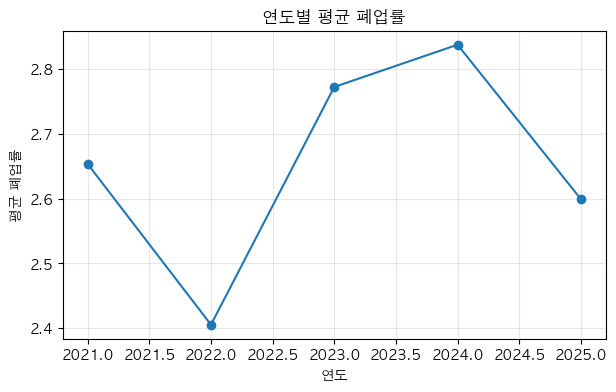

In [25]:
# 연도별 평균 폐업률
yearly_close = df_all.groupby('year', as_index=False)['close_rate'].mean()
display(yearly_close)

plt.figure(figsize=(7,4))
plt.plot(yearly_close['year'], yearly_close['close_rate'], marker='o')
plt.title('연도별 평균 폐업률')
plt.xlabel('연도')
plt.ylabel('평균 폐업률')
plt.grid(True, alpha=0.3)
plt.show()

,qtr,close_rate
0,1,2.9402
1,2,2.5616
2,3,2.7029
3,4,2.4095


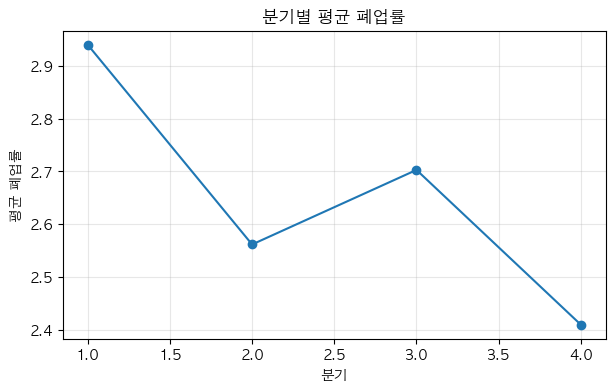

In [26]:
# 분기별 평균 폐업률

qtr_close = df_all.groupby('qtr', as_index=False)['close_rate'].mean()
display(qtr_close)

plt.figure(figsize=(7,4))
plt.plot(qtr_close['qtr'], qtr_close['close_rate'], marker='o')
plt.title('분기별 평균 폐업률')
plt.xlabel('분기')
plt.ylabel('평균 폐업률')
plt.grid(True, alpha=0.3)
plt.show()

,service,mean_close_rate,mean_store_cnt,rows
83,치킨전문점,11.4195,5.7207,8463
90,편의점,10.9916,5.8309,8500
89,패스트푸드점,8.8864,7.3690,8402
32,분식전문점,5.3731,21.4441,8484
84,커피-음료,5.3237,48.5432,8492
73,제과점,4.6253,12.1982,8441
65,일식음식점,4.6178,14.3132,8181
48,양식음식점,4.4893,18.3885,8259
72,전자상거래업,4.2478,54.9369,8484
79,중식음식점,4.0952,13.1970,8357


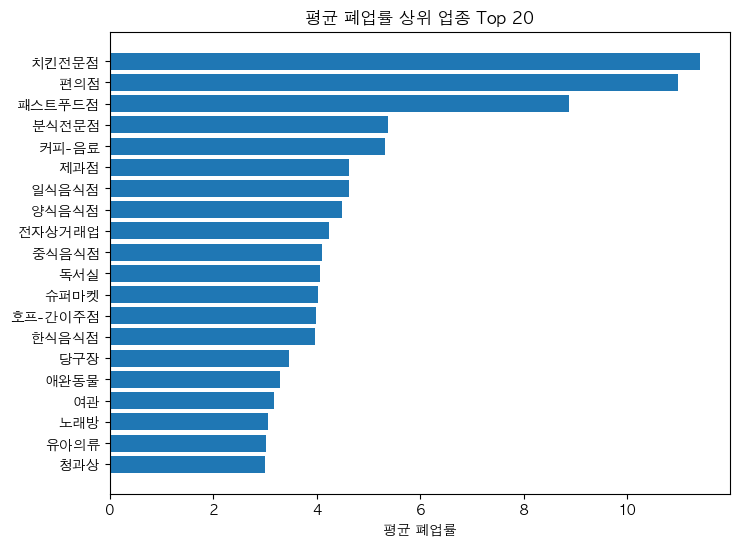

In [27]:
# 업종별 폐업률 
# 업종별 폐업률을 보면 어떤 업종군이 상대적으로 위험한지 파악할 수 있습니다.
# 단, 점포 수가 너무 적은 업종은 폐업률이 과도하게 튈 수 있으므로 평균 점포 수 기준 필터를 적용합니다.
service_summary = df_all.groupby('service').agg(
    mean_close_rate=('close_rate','mean'),
    mean_store_cnt=('store_cnt','mean'),
    rows=('service','size')
).reset_index()

service_summary_filtered = service_summary[service_summary['mean_store_cnt'] >= 5].copy()
top_service_risk = service_summary_filtered.sort_values('mean_close_rate', ascending=False).head(20)
display(top_service_risk)

plt.figure(figsize=(8,6))
plt.barh(top_service_risk.sort_values('mean_close_rate')['service'], top_service_risk.sort_values('mean_close_rate')['mean_close_rate'])
plt.title('평균 폐업률 상위 업종 Top 20')
plt.xlabel('평균 폐업률')
plt.show()

##### 핵심 EDA: 위험도가 높은 상권은 어떤 특징을 가지는가?

이 프로젝트의 핵심 연구 질문입니다.

여기서는 `low`와 `high` 위험 그룹을 비교합니다.

- `low`: 현재 폐업률 0
- `high`: 폐업률이 양수인 데이터 중 상위 25%

비교 변수는 사업성, 수요, 경쟁환경, 상권 안정성 관점으로 나눕니다.

In [28]:
compare_cols = [
    'close_rate', 'store_cnt', 'similar_store_cnt', 'open_rate', 'franchise_store_cnt',
    'sales_amt', 'sales_cnt', 'weekday_sales_amt', 'weekend_sales_amt',
    'worker_pop_total', 'resident_pop_total', 'floating_pop_total',
    'avg_operating_months', 'avg_closed_months'
]
compare_cols = [c for c in compare_cols if c in eda_df.columns]

risk_compare = eda_df[eda_df['risk_group'].isin(['low','high'])].groupby('risk_group')[compare_cols].mean().T
risk_compare['high_minus_low'] = risk_compare.get('high', np.nan) - risk_compare.get('low', np.nan)
risk_compare['high_div_low'] = risk_compare.get('high', np.nan) / risk_compare.get('low', np.nan).replace(0, np.nan)

display(risk_compare)

risk_group,high,low,high_minus_low,high_div_low
close_rate,19.2390,0.0000,19.2390,NaN
store_cnt,9.2188,13.1573,-3.9385,0.7007
similar_store_cnt,14.4385,14.6470,-0.2085,0.9858
open_rate,5.3414,2.0560,3.2854,2.5980
franchise_store_cnt,5.2197,1.4897,3.7300,3.5038
sales_amt,"695,950,846.7674","735,736,801.8214","-39,785,955.0540",0.9459
sales_cnt,"67,435.5924","30,101.9751","37,333.6173",2.2402
weekday_sales_amt,"514,256,837.2175","588,061,727.1392","-73,804,889.9217",0.8745
weekend_sales_amt,"181,694,009.5498","147,675,074.6822","34,018,934.8676",1.2304
worker_pop_total,"7,230.2985","8,747.9575","-1,517.6590",0.8265


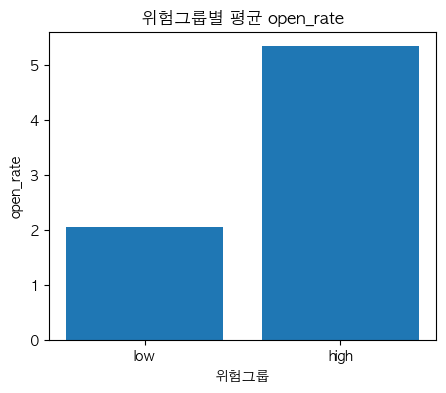

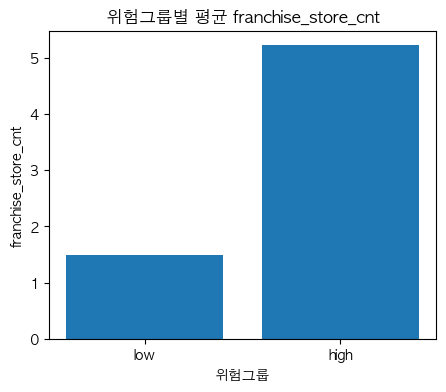

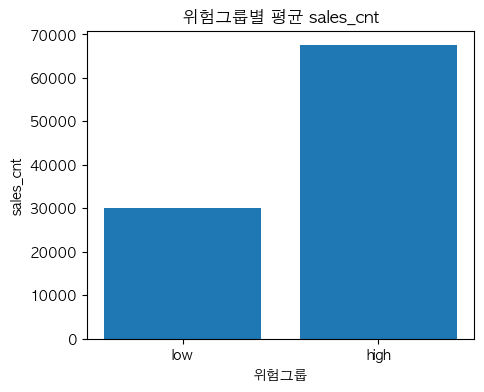

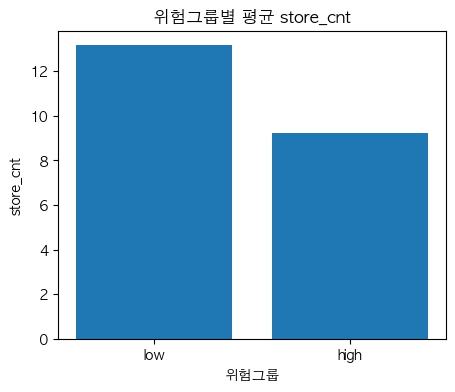

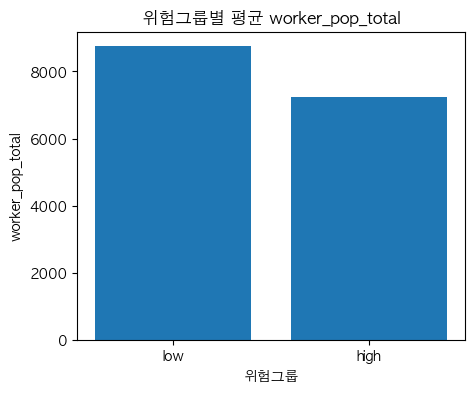

In [29]:
# 주요 변수 그래프 비교
plot_cols = [c for c in ['open_rate','franchise_store_cnt','sales_cnt','store_cnt','worker_pop_total'] if c in eda_df.columns]
# 점포수, 개업률, 프랜차이즈, 매출건수, 직장인구
for col in plot_cols:
    tmp = eda_df[eda_df['risk_group'].isin(['low','high'])].groupby('risk_group')[col].mean().reindex(['low','high'])
    plt.figure(figsize=(5,4))
    plt.bar(tmp.index, tmp.values)
    plt.title(f'위험그룹별 평균 {col}')
    plt.xlabel('위험그룹')
    plt.ylabel(col)
    plt.show()

# 고위험 상권은 
# 규모가 작음
# 진입과 퇴출이 활발
# 프랜차이즈 비중이 높음
# 거래는 많음
# 직장인 수요가 적음

위 표와 그래프를 보고 다음 문장 형태로 정리하면 면접 답변에 바로 사용할 수 있습니다.

> 고위험 상권은 저위험 상권에 비해 평균 폐업률과 개업률이 높았으며, 점포 수와 직장인구는 더 적은 경향을 보였다. 또한 매출금액은 다소 낮았지만 매출건수는 오히려 높게 나타나, 객단가가 낮고 회전율이 높은 상권일 가능성을 시사한다.

단, 이 단계는 인과관계가 아니라 **상관적 특징 분석**입니다. 인과관계라고 과장해서 말하면 안 됩니다.

,corr_with_close_rate
close_rate,1.0000
close_store_cnt,0.2274
open_rate,0.1881
franchise_store_cnt,0.1811
sales_cnt,0.0520
resident_pop_total,0.0198
similar_store_cnt,0.0047
floating_pop_total,0.0020
sales_amt,-0.0030
store_cnt,-0.0084


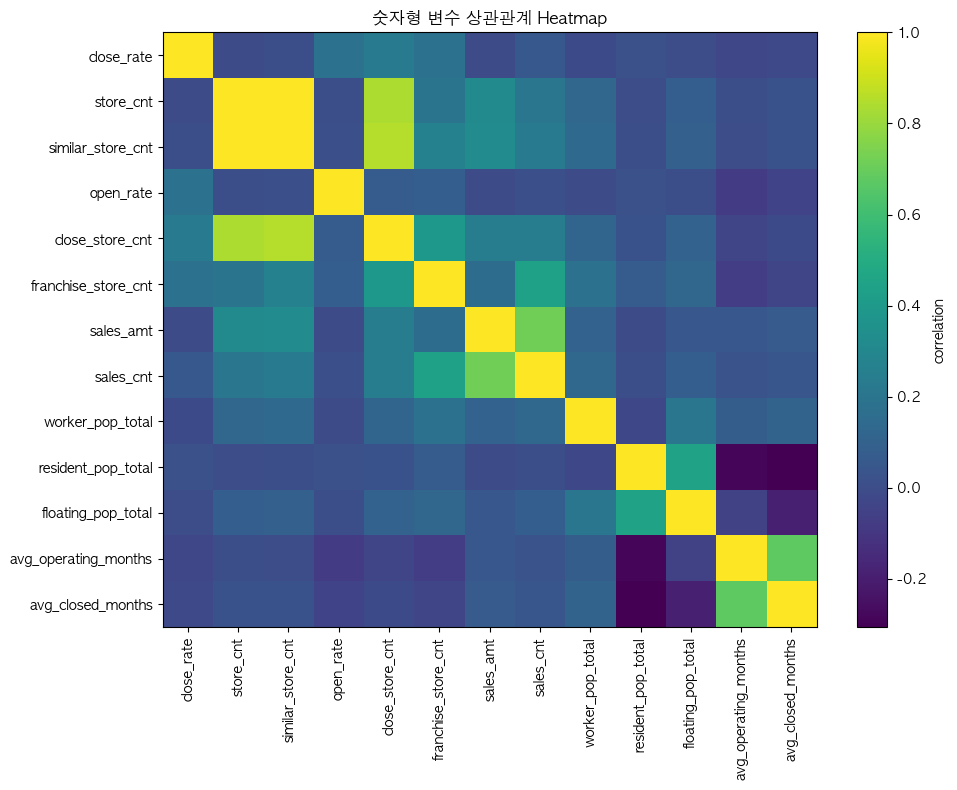

In [30]:
# 상관관계 분석

corr_cols = [
    'close_rate','store_cnt','similar_store_cnt','open_rate','close_store_cnt','franchise_store_cnt',
    'sales_amt','sales_cnt','worker_pop_total','resident_pop_total','floating_pop_total',
    'avg_operating_months','avg_closed_months'
]
corr_cols = [c for c in corr_cols if c in eda_df.columns]

corr = eda_df[corr_cols].corr(numeric_only=True)
display(corr['close_rate'].sort_values(ascending=False).to_frame('corr_with_close_rate'))

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('숫자형 변수 상관관계 Heatmap')
plt.tight_layout()
plt.show()

## 10. 머신러닝 기반 다음 분기 폐업위험 예측

이전 EDA에서는 현재 분기의 `close_rate`를 기준으로 위험군을 나누었다.
하지만 조기경보 시스템의 목적은 **현재 정보를 바탕으로 다음 분기의 폐업위험을 예측하는 것**이다.

따라서 모델링에서는 현재 분기 변수들을 입력값 `X`로 사용하고, 다음 분기의 폐업률인 `target_next_close_rate`를 이용해 타깃을 만든다.

타깃 정의는 EDA에서 사용한 기준과 동일하게 유지한다.

- `target_next_close_rate == 0` → `low`, target = 0
- `target_next_close_rate > 0` 중 상위 25% 이상 → `high`, target = 1
- 그 외의 `middle` → 모델 학습에서는 제외

이렇게 해야 폐업률 0이 많은 데이터 구조에서도 의미 있는 이진 분류 문제가 된다.

In [31]:
# =========================
# 10-1. 다음 분기 폐업률 타깃 생성
# =========================

# 모델링용 원본은 매출 데이터가 존재하는 df_sales_model을 사용한다.
# 현재 분기 특성으로 다음 분기 폐업위험을 예측하기 위해
# 행정동(dong_code) + 업종(service_code) 단위로 다음 분기의 close_rate를 가져온다.

df_model_base = df_sales_model.copy()

# 혹시 남아 있을 수 있는 year/qtr 중복 컬럼 정리
df_model_base = df_model_base.drop(columns=['year_x', 'qtr_x', 'year_y', 'qtr_y'], errors='ignore')

# quarter가 숫자형이 아닐 가능성에 대비
df_model_base['quarter'] = pd.to_numeric(df_model_base['quarter'], errors='coerce').astype('Int64')
df_model_base['year'] = (df_model_base['quarter'] // 10).astype('Int64')
df_model_base['qtr'] = (df_model_base['quarter'] % 10).astype('Int64')

# 다음 분기 코드 생성 함수
def get_next_quarter(q):
    if pd.isna(q):
        return np.nan
    q = int(q)
    year = q // 10
    quarter = q % 10
    if quarter < 4:
        return year * 10 + (quarter + 1)
    else:
        return (year + 1) * 10 + 1

# 정렬 후 같은 행정동-업종 내 다음 행의 폐업률을 가져온다.
key_cols = ['dong_code', 'service_code']
df_model_base = df_model_base.sort_values(key_cols + ['quarter']).copy()

df_model_base['next_quarter_expected'] = df_model_base['quarter'].apply(get_next_quarter).astype('Int64')
df_model_base['next_quarter_actual'] = df_model_base.groupby(key_cols)['quarter'].shift(-1).astype('Int64')
df_model_base['target_next_close_rate'] = df_model_base.groupby(key_cols)['close_rate'].shift(-1)

# 다음 행이 실제 다음 분기가 아닌 경우는 타깃으로 쓰지 않는다.
mask_not_consecutive = df_model_base['next_quarter_actual'] != df_model_base['next_quarter_expected']
df_model_base.loc[mask_not_consecutive, 'target_next_close_rate'] = np.nan

valid_target = df_model_base['target_next_close_rate'].dropna()
display(valid_target.describe().to_frame())

print('타깃 결측 행 수:', df_model_base['target_next_close_rate'].isna().sum())
print('타깃 사용 가능 행 수:', df_model_base['target_next_close_rate'].notna().sum())

,target_next_close_rate
count,"320,325.0000"
mean,3.0654
std,6.5120
min,0.0000
25%,0.0000
50%,0.0000
75%,4.0000
max,100.0000


타깃 결측 행 수: 22842
타깃 사용 가능 행 수: 320325


### 10-2. 다음 분기 위험군 생성

`target_next_close_rate`도 현재 폐업률과 마찬가지로 0이 매우 많다.
따라서 전체 분위수 `q1/q2/q3`로 A/B/C/D를 나누면 25%, 50%, 75% 분위수가 모두 0이 되어 위험등급이 의미 없어진다.

그래서 다음 기준을 사용한다.

- 다음 분기 폐업률이 0이면 `low`
- 다음 분기 폐업률이 양수인 데이터 중 상위 25% 이상이면 `high`
- 그 사이는 `middle`로 두고 모델링에서는 제외한다.

In [32]:
# =========================
# 10-2. 다음 분기 폐업위험군 생성
# =========================

positive_target = valid_target[valid_target > 0]
high_threshold_next = positive_target.quantile(0.75) if len(positive_target) > 0 else np.nan

print('target_next_close_rate > 0 데이터의 75% 분위수:', high_threshold_next)

def make_risk_group_next(x):
    if pd.isna(x):
        return np.nan
    elif x == 0:
        return 'low'
    elif x >= high_threshold_next:
        return 'high'
    else:
        return 'middle'

df_model_base['risk_group_next'] = df_model_base['target_next_close_rate'].apply(make_risk_group_next)

print(df_model_base['risk_group_next'].value_counts(dropna=False))
display(df_model_base[['quarter','next_quarter_actual','dong','service','close_rate','target_next_close_rate','risk_group_next']].head(10))

target_next_close_rate > 0 데이터의 75% 분위수: 11.11111111111111
risk_group_next
low       207354
middle     84314
high       28657
NaN        22842
Name: count, dtype: int64


,quarter,next_quarter_actual,dong,service,close_rate,target_next_close_rate,risk_group_next
141235,20211,20212,청운효자동,한식음식점,3.8961,9.3333,middle
176340,20212,20213,청운효자동,한식음식점,9.3333,5.3333,middle
211428,20213,20214,청운효자동,한식음식점,5.3333,2.7027,middle
246509,20214,20221,청운효자동,한식음식점,2.7027,4.0000,middle
422848,20221,20222,청운효자동,한식음식점,4.0000,1.3699,middle
457972,20222,20223,청운효자동,한식음식점,1.3699,1.3699,middle
493101,20223,20224,청운효자동,한식음식점,1.3699,1.3333,middle
528261,20224,20231,청운효자동,한식음식점,1.3333,3.8961,middle
0,20231,20232,청운효자동,한식음식점,3.8961,0.0000,low
35261,20232,20233,청운효자동,한식음식점,0.0000,2.6316,middle


In [33]:
# =========================
# 10-3. 이진 분류용 데이터 생성
# =========================

# low와 high만 남긴다. middle은 경계가 애매하므로 학습에서 제외한다.
df_model_binary = df_model_base[df_model_base['risk_group_next'].isin(['low', 'high'])].copy()

df_model_binary['target'] = (df_model_binary['risk_group_next'] == 'high').astype(int)

target_summary = pd.DataFrame({
    'count': df_model_binary['target'].value_counts().sort_index(),
    'ratio(%)': (df_model_binary['target'].value_counts(normalize=True).sort_index() * 100).round(2)
})
target_summary.index = ['Low Risk (0)', 'High Risk (1)']

display(target_summary)
print('모델링 데이터 크기:', df_model_binary.shape)

,count,ratio(%)
Low Risk (0),207354,87.8600
High Risk (1),28657,12.1400


모델링 데이터 크기: (236011, 30)


### 10-4. Feature / Target 분리

주의할 점은 현재 분기의 `close_rate`, 다음 분기의 `target_next_close_rate`, 위험군 라벨 등은 입력 변수에서 제외해야 한다는 것이다.

즉 모델은 **현재 분기 상권 특성**만 보고 **다음 분기 폐업위험**을 예측한다.

In [34]:
# =========================
# 10-4. Feature / Target 분리
# =========================

exclude_cols = [
    # 타깃 및 라벨
    'target',
    'risk_group',
    'risk_group_next',
    'target_next_close_rate',
    'next_quarter_expected',
    'next_quarter_actual',

    # 현재/미래 폐업 관련 직접 변수: 데이터 누수 방지
    'close_rate',
    'close_store_cnt',

    # 식별자 및 설명용 컬럼
    'quarter',
    'year',
    'qtr',
    'dong',
    'service'
]

feature_cols = [c for c in df_model_binary.columns if c not in exclude_cols]

X = df_model_binary[feature_cols].copy()
y = df_model_binary['target'].copy()

print('사용 변수 개수:', len(feature_cols))
print(feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)

사용 변수 개수: 18
['dong_code', 'service_code', 'store_cnt', 'similar_store_cnt', 'open_rate', 'open_store_cnt', 'franchise_store_cnt', 'sales_amt', 'sales_cnt', 'weekday_sales_amt', 'weekend_sales_amt', 'worker_pop_total', 'resident_pop_total', 'floating_pop_total', 'change_indicator', 'change_indicator_name', 'avg_operating_months', 'avg_closed_months']
X shape: (236011, 18)
y shape: (236011,)


### 10-5. 학습 속도 조절

데이터가 매우 크기 때문에 전체 데이터를 그대로 사용하면 맥북 환경에서 시간이 오래 걸릴 수 있다.
모델 비교 단계에서는 최대 100,000개를 샘플링해 빠르게 실험하고, 최종 필요 시 샘플 수를 늘릴 수 있다.

In [35]:
# =========================
# 10-5. 학습용 샘플링
# =========================

# pandas의 sample()에는 stratify 옵션이 없으므로,
# train_test_split의 stratify 기능을 이용해 target 비율을 유지한 샘플을 만든다.

from sklearn.model_selection import train_test_split

MAX_SAMPLE = 100_000

if len(df_model_binary) > MAX_SAMPLE:
    df_train_base, _ = train_test_split(
        df_model_binary,
        train_size=MAX_SAMPLE,
        random_state=42,
        stratify=df_model_binary['target']
    )
else:
    df_train_base = df_model_binary.copy()

X = df_train_base[feature_cols].copy()
y = df_train_base['target'].copy()

print('학습에 사용할 데이터 크기:', X.shape)
display(
    pd.DataFrame({
        'count': y.value_counts().sort_index(),
        'ratio(%)': (y.value_counts(normalize=True).sort_index() * 100).round(2)
    }).rename(index={0: 'Low Risk (0)', 1: 'High Risk (1)'})
)

학습에 사용할 데이터 크기: (100000, 18)


,count,ratio(%)
target,,
Low Risk (0),87858,87.8600
High Risk (1),12142,12.1400


In [36]:
# =========================
# 10-6. 전처리 및 Train/Test Split
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=['int64', 'float64', 'Int64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train 비율')
print(y_train.value_counts(normalize=True).sort_index())

X_train: (80000, 18)
X_test : (20000, 18)
y_train 비율
target
0   0.8786
1   0.1214
Name: proportion, dtype: float64


## 11. 여러 모델 비교

설치 문제가 발생하기 쉬운 XGBoost/LightGBM에 의존하지 않고, `scikit-learn` 기본 모델을 중심으로 비교한다.

- Logistic Regression: 기준 모델
- Decision Tree: 해석이 쉬운 단일 트리
- Random Forest: 배깅 기반 앙상블
- Extra Trees: 랜덤성을 더 강화한 앙상블
- Gradient Boosting: 부스팅 기반 모델
- Stacking Ensemble: 여러 모델을 결합한 확장 실험

Stacking은 계산량이 크므로 가볍게 구성했다.

In [37]:
# =========================
# 11-1. 모델 정의
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# Stacking은 계산량을 줄이기 위해 가벼운 구조로 추가
stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=500, class_weight='balanced')),
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')),
        ('rf', RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1))
    ],
    final_estimator=LogisticRegression(max_iter=500),
    cv=2,
    n_jobs=-1
)

models['Stacking Ensemble'] = stacking_model

print('비교 모델:', list(models.keys()))

비교 모델: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'Stacking Ensemble']


In [38]:
# =========================
# 11-2. 모델 학습 및 성능 비교
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
fitted_models = {}

for name, model in models.items():
    print(f'학습 중: {name}')

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob)
    })

    fitted_models[name] = pipe

model_results = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
display(model_results)

학습 중: Logistic Regression
학습 중: Decision Tree
학습 중: Random Forest
학습 중: Extra Trees
학습 중: Gradient Boosting
학습 중: Stacking Ensemble


,model,accuracy,precision,recall,f1,roc_auc
5,Stacking Ensemble,0.8809,0.5296,0.1660,0.2527,0.7854
4,Gradient Boosting,0.8832,0.6090,0.1058,0.1804,0.7802
2,Random Forest,0.7883,0.3029,0.5717,0.3960,0.7778
0,Logistic Regression,0.7296,0.2569,0.6483,0.3679,0.7613
1,Decision Tree,0.7660,0.2734,0.5597,0.3673,0.7592
3,Extra Trees,0.8097,0.3236,0.5206,0.3991,0.7586


In [39]:
# =========================
# 11-3. 최종 모델 선택
# =========================

best_model_name = model_results.iloc[0]['model']
best_model = fitted_models[best_model_name]

print('Best Model:', best_model_name)
display(model_results.head(1))

Best Model: Stacking Ensemble


,model,accuracy,precision,recall,f1,roc_auc
5,Stacking Ensemble,0.8809,0.5296,0.1660,0.2527,0.7854


              precision    recall  f1-score   support

    Low Risk       0.89      0.98      0.94     17572
   High Risk       0.53      0.17      0.25      2428

    accuracy                           0.88     20000
   macro avg       0.71      0.57      0.59     20000
weighted avg       0.85      0.88      0.85     20000



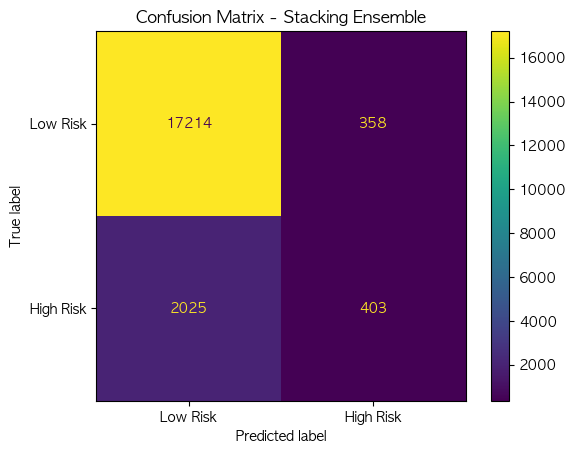

In [40]:
# =========================
# 11-4. Confusion Matrix + Classification Report
# =========================

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred, target_names=['Low Risk', 'High Risk'], zero_division=0))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

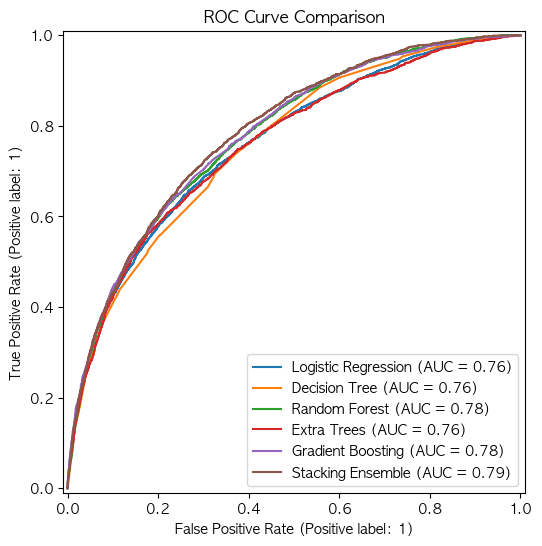

In [41]:
# =========================
# 11-5. ROC Curve 비교
# =========================

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title('ROC Curve Comparison')
plt.show()

## 12. Explainable AI

모델이 어떤 변수를 중요하게 사용했는지 확인한다.

- 트리 기반 모델이면 `feature_importances_`를 확인한다.
- 모델 종류와 무관하게 비교할 수 있도록 `Permutation Importance`도 함께 사용한다.

Permutation Importance는 시간이 오래 걸릴 수 있으므로 테스트 데이터 중 최대 20,000개만 사용한다.

In [42]:
# =========================
# 12-1. Feature Importance
# =========================

final_model = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

if hasattr(final_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance.head(20))

    importance.head(20).sort_values('importance').plot(
        x='feature',
        y='importance',
        kind='barh',
        figsize=(8, 6)
    )
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()
else:
    print(f'{best_model_name}은 feature_importances_를 직접 제공하지 않습니다. Permutation Importance를 확인하세요.')

Stacking Ensemble은 feature_importances_를 직접 제공하지 않습니다. Permutation Importance를 확인하세요.


,feature,importance_mean,importance_std
6,franchise_store_cnt,0.0702,0.0020
1,service_code,0.0550,0.0022
2,store_cnt,0.0474,0.0021
3,similar_store_cnt,0.0149,0.0004
5,open_store_cnt,0.0033,0.0002
4,open_rate,0.0032,0.0008
9,weekday_sales_amt,0.0028,0.0003
0,dong_code,0.0021,0.0006
8,sales_cnt,0.0014,0.0002
7,sales_amt,0.0010,0.0002


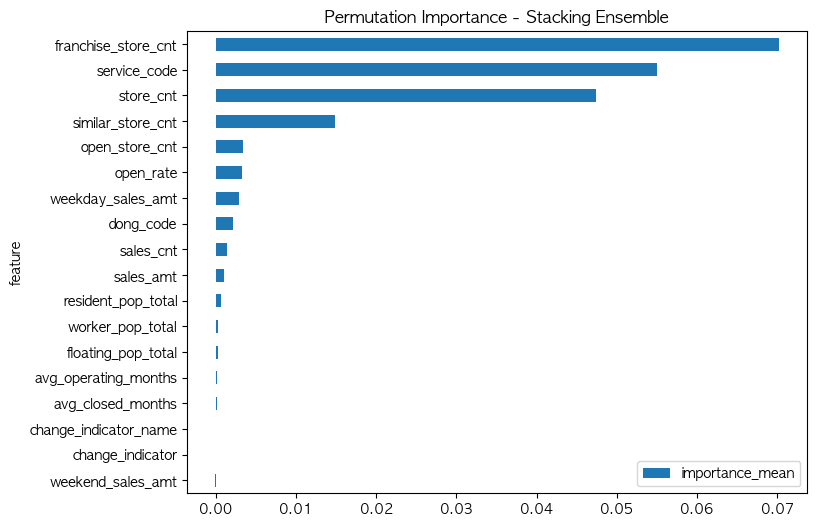

In [43]:
# =========================
# 12-2. Permutation Importance
# =========================

from sklearn.inspection import permutation_importance

# 속도 조절: 테스트 데이터 중 일부만 사용
PERM_SAMPLE = 20_000

if len(X_test) > PERM_SAMPLE:
    X_test_perm = X_test.sample(n=PERM_SAMPLE, random_state=42)
    y_test_perm = y_test.loc[X_test_perm.index]
else:
    X_test_perm = X_test.copy()
    y_test_perm = y_test.copy()

perm_result = permutation_importance(
    best_model,
    X_test_perm,
    y_test_perm,
    n_repeats=3,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'feature': X_test_perm.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_importance.head(20))

perm_importance.head(20).sort_values('importance_mean').plot(
    x='feature',
    y='importance_mean',
    kind='barh',
    figsize=(8, 6)
)
plt.title(f'Permutation Importance - {best_model_name}')
plt.show()

## 13. AI Early Warning System

최종 모델의 예측 확률을 이용해 다음 분기 폐업위험을 조기경보 형태로 제공한다.

- `risk_probability`: 다음 분기 고위험 상권으로 분류될 확률
- `warning_level`: 확률 기반 경보 등급
- Top20 위험 상권: 정책 지원·컨설팅 우선 검토 대상 후보

In [59]:
# =========================
# 13-1. 위험확률 및 경보등급 생성
# =========================

df_warning = df_train_base.loc[X_test.index].copy()

df_warning['risk_probability'] = best_model.predict_proba(X_test)[:, 1]
df_warning['predicted_target'] = best_model.predict(X_test)

def risk_level(p):
    if p >= 0.6:
        return '🔴 High'
    elif p >= 0.40:
        return '🟡 Medium'
    else:
        return '🟢 Low'

df_warning['warning_level'] = df_warning['risk_probability'].apply(risk_level)

display(df_warning[['quarter','dong','service','close_rate','target_next_close_rate','risk_probability','warning_level']].head())

,quarter,dong,service,close_rate,target_next_close_rate,risk_probability,warning_level
603344,20242,금호4가동,노래방,0.0000,0.0000,0.1303,🟢 Low
611774,20242,월계3동,치킨전문점,0.0000,0.0000,0.4204,🟡 Medium
170469,20211,방배4동,스포츠 강습,0.0000,0.0000,0.0434,🟢 Low
544968,20224,북가좌2동,예술학원,0.0000,0.0000,0.0598,🟢 Low
478738,20222,발산1동,양식음식점,0.0000,17.3913,0.1873,🟢 Low


In [60]:
# =========================
# 13-2. 폐업 위험 상권 TOP 20
# =========================

top20_risk = df_warning.sort_values('risk_probability', ascending=False)[[
    'quarter',
    'next_quarter_actual',
    'dong',
    'service',
    'close_rate',
    'target_next_close_rate',
    'risk_group_next',
    'risk_probability',
    'warning_level'
]].head(20)

display(top20_risk)

,quarter,next_quarter_actual,dong,service,close_rate,target_next_close_rate,risk_group_next,risk_probability,warning_level
655719,20243,20244,구로3동,편의점,23.5294,18.7500,high,0.6220,🔴 High
276440,20214,20221,압구정동,편의점,23.0769,16.6667,high,0.6190,🔴 High
551449,20224,20231,시흥1동,편의점,28.5714,16.6667,high,0.6148,🔴 High
584411,20241,20242,발산1동,편의점,33.3333,14.2857,high,0.6147,🔴 High
372883,20253,20254,가양1동,편의점,26.0870,14.2857,high,0.6145,🔴 High
176194,20211,20212,길동,편의점,20.0000,14.2857,high,0.6136,🔴 High
472624,20222,20223,갈현2동,편의점,14.2857,0.0000,low,0.6114,🔴 High
273901,20214,20221,신사동,편의점,14.2857,0.0000,low,0.6100,🔴 High
14067,20231,20232,상계6·7동,편의점,20.0000,20.0000,high,0.6091,🔴 High
646671,20243,20244,방학1동,편의점,14.2857,0.0000,low,0.6088,🔴 High


AI EARLY WARNING DASHBOARD
최종 모델: Stacking Ensemble
분석 대상 수: 20000
평균 위험확률: 0.1222

🔴 High: 31
🟡 Medium: 1,324
🟢 Low: 18,645


/Users/gang-ga-eun/Downloads/금융프로젝트/ai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gang-ga-eun/Downloads/금융프로젝트/ai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/gang-ga-eun/Downloads/금융프로젝트/ai_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


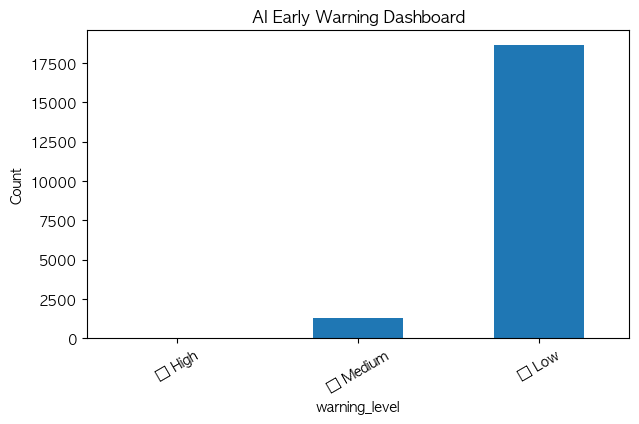

In [61]:
# =========================
# 13-3. Early Warning Dashboard 요약
# =========================

warning_counts = df_warning['warning_level'].value_counts().reindex(
    ['🔴 High','🟡 Medium', '🟢 Low'],
    fill_value=0
)

print('=' * 50)
print('AI EARLY WARNING DASHBOARD')
print('=' * 50)
print('최종 모델:', best_model_name)
print('분석 대상 수:', len(df_warning))
print('평균 위험확률:', round(df_warning['risk_probability'].mean(), 4))
print()
for level, count in warning_counts.items():
    print(f'{level}: {count:,}')
print('=' * 50)

plt.figure(figsize=(7,4))
warning_counts.plot(kind='bar')
plt.title('AI Early Warning Dashboard')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

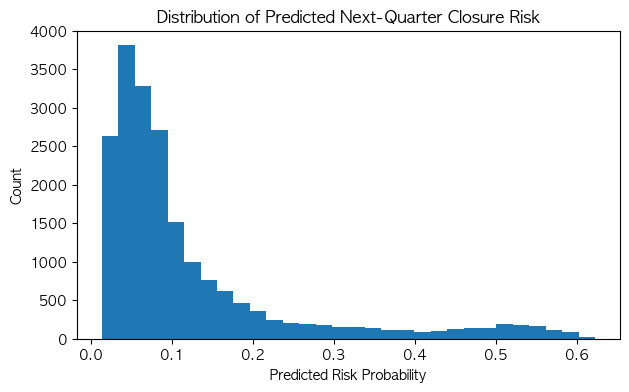

In [62]:
# =========================
# 13-4. 위험확률 분포
# =========================

plt.figure(figsize=(7,4))
plt.hist(df_warning['risk_probability'], bins=30)
plt.xlabel('Predicted Risk Probability')
plt.ylabel('Count')
plt.title('Distribution of Predicted Next-Quarter Closure Risk')
plt.show()

In [54]:
# =========================
# 13-5. 동별 / 업종별 평균 위험도
# =========================

dong_rank = (
    df_warning
    .groupby('dong')['risk_probability']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

service_rank = (
    df_warning
    .groupby('service')['risk_probability']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

print('동별 평균 위험확률 Top 20')
display(dong_rank.to_frame('mean_risk_probability'))

print('업종별 평균 위험확률 Top 20')
display(service_rank.to_frame('mean_risk_probability'))

동별 평균 위험확률 Top 20


,mean_risk_probability
dong,
위례동,0.3096
항동,0.2908
고덕2동,0.2428
명일2동,0.2086
사근동,0.2045
가양1동,0.2017
신정6동,0.1937
진관동,0.1936
등촌1동,0.1909


업종별 평균 위험확률 Top 20


,mean_risk_probability
service,
편의점,0.4754
치킨전문점,0.4571
패스트푸드점,0.3892
커피-음료,0.3265
분식전문점,0.3074
제과점,0.2333
슈퍼마켓,0.2133
한식음식점,0.1920
일식음식점,0.1841


## 14. 최종 해석 및 활용 방안

본 프로젝트는 현재 분기의 상권·매출·인구·경쟁환경 데이터를 활용해 **다음 분기 폐업 고위험 상권**을 예측하는 조기경보 모델을 구축하였다.

분위수 전체 구간으로 위험등급을 나누는 방식은 폐업률 0이 많은 데이터 구조에서는 적절하지 않으므로, 다음 분기 폐업률이 0인 상권을 저위험으로, 폐업이 발생한 상권 중 상위 25%를 고위험으로 정의하였다.

최종적으로 여러 머신러닝 모델을 비교하고 ROC-AUC 기준으로 최적 모델을 선정했으며, Feature Importance와 Permutation Importance를 통해 예측에 영향을 미치는 주요 요인을 해석하였다.

### 활용 방안

- 예측 위험확률이 높은 상권을 정책 모니터링 대상으로 지정
- 소상공인 컨설팅, 자금지원, 경영개선 프로그램의 우선순위 설정
- 지역별·업종별 위험도 변화를 정기적으로 추적하는 조기경보 체계 구축
- Explainable AI 기반 변수 중요도 분석을 통해 정책 의사결정 근거 제공

### 주의점

이 분석은 상관관계 기반 예측모델이며, 특정 변수가 폐업을 직접 유발한다고 단정할 수 없다. 또한 서울시 상권 데이터의 폐업률은 분기 말 운영 점포 수 대비 해당 분기 폐업 점포 수로 계산되어 100을 초과할 수 있으므로, 해석 시 지표 정의를 함께 설명해야 한다.